# EDA, Limpieza y transformación de datos

**Autor(es):** Sebastian Bustos, Nicolás Parada, Genesis Parada y Jorge Rocha.

**Correo Electrónico:** sebastian.bustos2301@alumnos.ubiobio.cl, nicolas.parada2301@alumnos.ubiobio.cl, genesis.parada2301@alumnos.ubiobio.cl, jorge.rocha2301@alumnos.ubiobio.cl

**Fecha de Creación:** Septiembre de 2026

**Versión:** 1.0

---

## Descripción

*Desarrollo de proceso de diagnóstico, análisis exploratorio y preparación de datos del rendimiento académico de estudiantes.*

---

## Objetivo

Realizar un análisis exploratorio de datos para luego realizar la limpieza y transformación del set de datos `rendimiento_academico_evaluacion.csv` con la finalidad de preparar los datos para posibles modelos predictivos.


---

## Requisitos de Software

Este notebook fue desarrollado con Python 3.12. A continuación se listan las bibliotecas necesarias:

- pandas (>=1.1.0)
- matplotlib (3.7.1)
- numpy (2.0.2)

Para verificar la versión instalada ejecutar usando el siguiente comando, usando la librería de la cual quieres saber la versión:

```python
import pandas as pd
print(pd.__version__)

##Fuentes de datos

In [ ]:
!wget https://raw.githubusercontent.com/898jorge/EntregasIA/refs/heads/main/E1%20–%20EDA/rendimiento_academico_evaluacion.csv

--2026-09-04 03:56:31--  https://raw.githubusercontent.com/898jorge/EntregasIA/refs/heads/main/E1%20%E2%80%93%20EDA/rendimiento_academico_evaluacion.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 382638 (374K) [text/plain]
Saving to: ‘rendimiento_academico_evaluacion.csv.3’

rendimiento_academi 100%[===================>] 373.67K  --.-KB/s    in 0.03s   

2026-09-04 03:56:31 (10.8 MB/s) - ‘rendimiento_academico_evaluacion.csv.3’ saved [382638/382638]



# Contexto de negocio

El conjunto de datos proviene de una institución de educación superior que busca analizar el rendimiento académico de sus estudiantes.

El archivo `rendimiento_academico_evaluacion.csv` contiene información relacionada con las características demográficas, hábitos de estudio, antecedentes académicos y el rendimiento final de un conjunto de estudiantes.

El objetivo es diagnosticar la calidad de los datos, tratarlos y dejarlos preparados para futuros análisis o posibles modelos predictivos.

# Metadata

| Nombre de Variable | Tipo de Dato | Naturaleza / Escala | Descripción de Negocio |
| --- | --- | --- | --- |
| **`StudentID`** | Texto (`object`) | Nominal / Identificador | Código único de identificación del estudiante. No tiene valor predictivo. |
| **`Age`** | Flotante (`float64`) | Numérica Continua | Edad del estudiante. |
| **`StudyHours`** | Flotante (`float64`) | Numérica Continua | Horas dedicadas al estudio. |
| **`Attendance`** | Flotante (`float64`) | Numérica Continua | Porcentaje o índice de asistencia a clases. |
| **`PreviousGPA`** | Flotante (`float64`) | Numérica Continua | Promedio académico general previo. |
| **`AssignmentsCompleted`**| Flotante (`float64`) | Numérica Continua | Cantidad o porcentaje de tareas completadas. |
| **`SleepHours`** | Flotante (`float64`) | Numérica Continua | Horas promedio de sueño. |
| **`InternetHours`** | Flotante (`float64`) | Numérica Continua | Horas dedicadas al uso de internet. |
| **`Scholarship`** | Texto (`object`) | Categórica Binaria | Indica si el estudiante tiene beca (Sí / No). |
| **`Program`** | Texto (`object`) | Categórica Nominal | Programa académico o carrera (ej. Ingeniería Industrial, Contador Auditor). |
| **`FinalGrade`** | Flotante (`float64`) | Numérica Continua | Calificación final del estudiante. Esta es la **variable objetivo** a mantener separada[cite: 4]. |

## Caracterización del dataset

A partir de la carga e inspección inicial de los datos, podemos caracterizar el dataset de la siguiente manera:



*   Cantidad de registros (observaciones): 5.100 estudiantes.
*   Cantidad de variables (columnas): 11 variables en total.


*   Tipos de datos: El dataset se compone de 8 variables numéricas de tipo punto flotante (float64) y 3 variables de tipo texto (object).

*   Variables Numéricas Continuas: Age, StudyHours, Attendance, PreviousGPA, AssignmentsCompleted, SleepHours e InternetHours.

*   Variables Categóricas: Scholarship (Beca) y Program (Carrera académica).
*   Variable Identificadora: StudentID corresponde al código único de identificación de cada estudiante. Al no tener valor predictivo, no será considerada para el entrenamiento de modelos.


*   Variable Objetivo (Target): FinalGrade representa la calificación final del estudiante y es la variable que se busca predecir o analizar, por lo que debe mantenerse aislada durante las transformaciones.











  

  

  

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

In [ ]:
data = pd.read_csv("rendimiento_academico_evaluacion.csv")
data.shape

(5100, 11)

# Diagnóstico de calidad


## Valores faltantes (Nulos)

In [ ]:
null_summary = pd.DataFrame(
    {
        "Nulos_Absolutos": data.isnull().sum(),
        "Porcentaje_Nulos": round((data.isnull().sum() / len(data)) * 100, 2),
    }
)
print(null_summary[null_summary["Nulos_Absolutos"] > 0])
print("\n")

                      Nulos_Absolutos  Porcentaje_Nulos
Age                               103              2.02
StudyHours                        181              3.55
Attendance                        224              4.39
PreviousGPA                       162              3.18
AssignmentsCompleted              216              4.24
SleepHours                        122              2.39
InternetHours                     176              3.45
Scholarship                        81              1.59
Program                            70              1.37




/tmp/ipykernel_5046/453357363.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=porcentaje_nulos.values, y=porcentaje_nulos.index, palette='Blues_r')


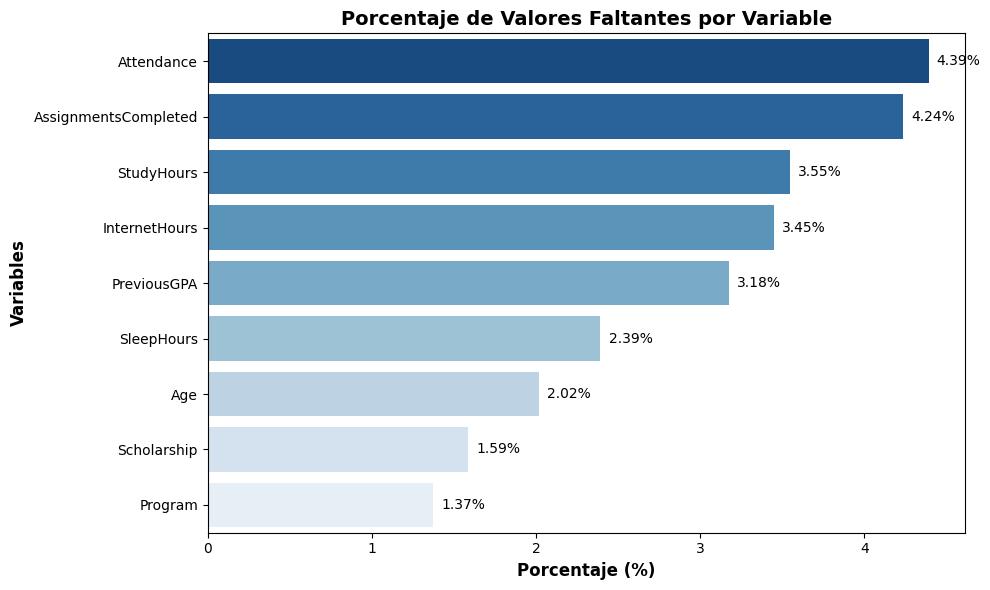

In [ ]:
# 1. Calcular el porcentaje de nulos por columna
porcentaje_nulos = (data.isnull().sum() / len(data)) * 100

# 2. Filtrar solo las que tienen nulos y ordenarlas de mayor a menor
porcentaje_nulos = porcentaje_nulos[porcentaje_nulos > 0].sort_values(ascending=False)

# 3. Crear el gráfico de barras horizontales
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=porcentaje_nulos.values, y=porcentaje_nulos.index, palette='Blues_r')

# 4. Configuraciones visuales (títulos y etiquetas)
plt.title('Porcentaje de Valores Faltantes por Variable', fontsize=14, fontweight='bold')
plt.xlabel('Porcentaje (%)', fontsize=12, fontweight='bold')
plt.ylabel('Variables', fontsize=12, fontweight='bold')

# 5. Agregar el valor numérico al final de cada barra
for i, v in enumerate(porcentaje_nulos.values):
    ax.text(v + 0.05, i, f"{v:.2f}%", color='black', va='center')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

### Análisis de Valores Faltantes

El gráfico revela que el dataset presenta un nivel muy bajo y manejable de datos nulos, donde ninguna variable supera el 4.4% de ausencia. Las variables con mayor proporción de valores faltantes son la asistencia (`Attendance` con 4.39%) y las tareas completadas (`AssignmentsCompleted` con 4.24%), mientras que variables categóricas como el programa académico (`Program` con 1.37%) son las más completas. Dado que la pérdida de información es mínima en términos porcentuales, no se compromete la estructura general del dataset; esto justifica técnicamente la decisión de aplicar estrategias de imputación (media, mediana y moda) en lugar de eliminar observaciones o columnas, garantizando así la conservación de la mayor cantidad de datos útiles para el futuro modelado.

## Duplicados

In [ ]:
total_duplicates = data.duplicated().sum()
print(f"Cantidad de filas duplicadas identificadas: {total_duplicates}")

Cantidad de filas duplicadas identificadas: 100


In [ ]:
# Muestra los registros duplicados en el DataFrame
data[data.duplicated(keep=False)].sort_values(by="StudentID").head(10)

,StudentID,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours,Scholarship,Program,FinalGrade
5017,STU-10014,24.0,21.21,91.56,5.67,97.82,6.37,10.60,No,Ingeniería Civil,4.87
4895,STU-10014,24.0,21.21,91.56,5.67,97.82,6.37,10.60,No,Ingeniería Civil,4.87
1437,STU-10028,21.0,12.94,80.47,5.96,NaN,7.47,5.39,No,Ingeniería Industrial,3.11
3572,STU-10028,21.0,12.94,80.47,5.96,NaN,7.47,5.39,No,Ingeniería Industrial,3.11
736,STU-10043,22.0,2.34,78.24,4.75,35.87,7.79,2.44,No,Administración,1.78
4829,STU-10043,22.0,2.34,78.24,4.75,35.87,7.79,2.44,No,Administración,1.78
4179,STU-10063,30.0,18.19,91.83,6.43,100.00,7.16,3.04,Sí,Ingeniería Industrial,4.90
2471,STU-10063,30.0,18.19,91.83,6.43,100.00,7.16,3.04,Sí,Ingeniería Industrial,4.90
2000,STU-10095,22.0,10.62,56.34,5.60,70.73,7.96,4.03,NaN,Ingeniería Civil,3.43
2568,STU-10095,22.0,10.62,56.34,5.60,70.73,7.96,4.03,NaN,Ingeniería Civil,3.43


###Registros duplicados

* **Cantidad de registros duplicados:** 100
* **Porcentaje respecto al dataset:** 1,96%
* **Variable identificadora:** Cabe destacar que la variable que identifica a cada registro de manera única en este dataset es **`StudentID`**.

Se procederá a la eliminación de las observaciones que son copias exactas. Mantener registros idénticos genera un sobreajuste al otorgar un peso artificial y redundante a ciertas observaciones, lo que sesgaría los resultados del análisis exploratorio y de cualquier modelo predictivo posterior.

## Deteccion de Outliers

In [ ]:
def diagnostico_outliers_iqr(dataframe: pd.DataFrame, columna: str):
  """
  Diagnóstico de valores atípicos

  Parámetros
  ----------
  dataframe: pd.DataFrame
    Set de datos a analizar
  columna: str
    Nombre de la columna a analizar

  Retorna
  -------
  outliers: pd.DataFrame
    Registros atípicos encontrados

  """
  Q1 = dataframe[columna].quantile(0.25)
  Q3 = dataframe[columna].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  # Aislamiento de registros atípicos
  outliers = dataframe[
        (dataframe[columna] < lower_bound) | (dataframe[columna] > upper_bound)
  ]

  print(f"--- Análisis IQR para la variable '{columna}' ---")
  print(f"Q1: {Q1:.2f} | Q3: {Q3:.2f} | IQR: {IQR:.2f}")
  print(f"Límite Inferior: {lower_bound:.2f} | Límite Superior: {upper_bound:.2f}")
  print(f"Registros fuera de límites: {len(outliers)} ({(len(outliers)/len(dataframe))*100:.2f}%)\n")
  return outliers

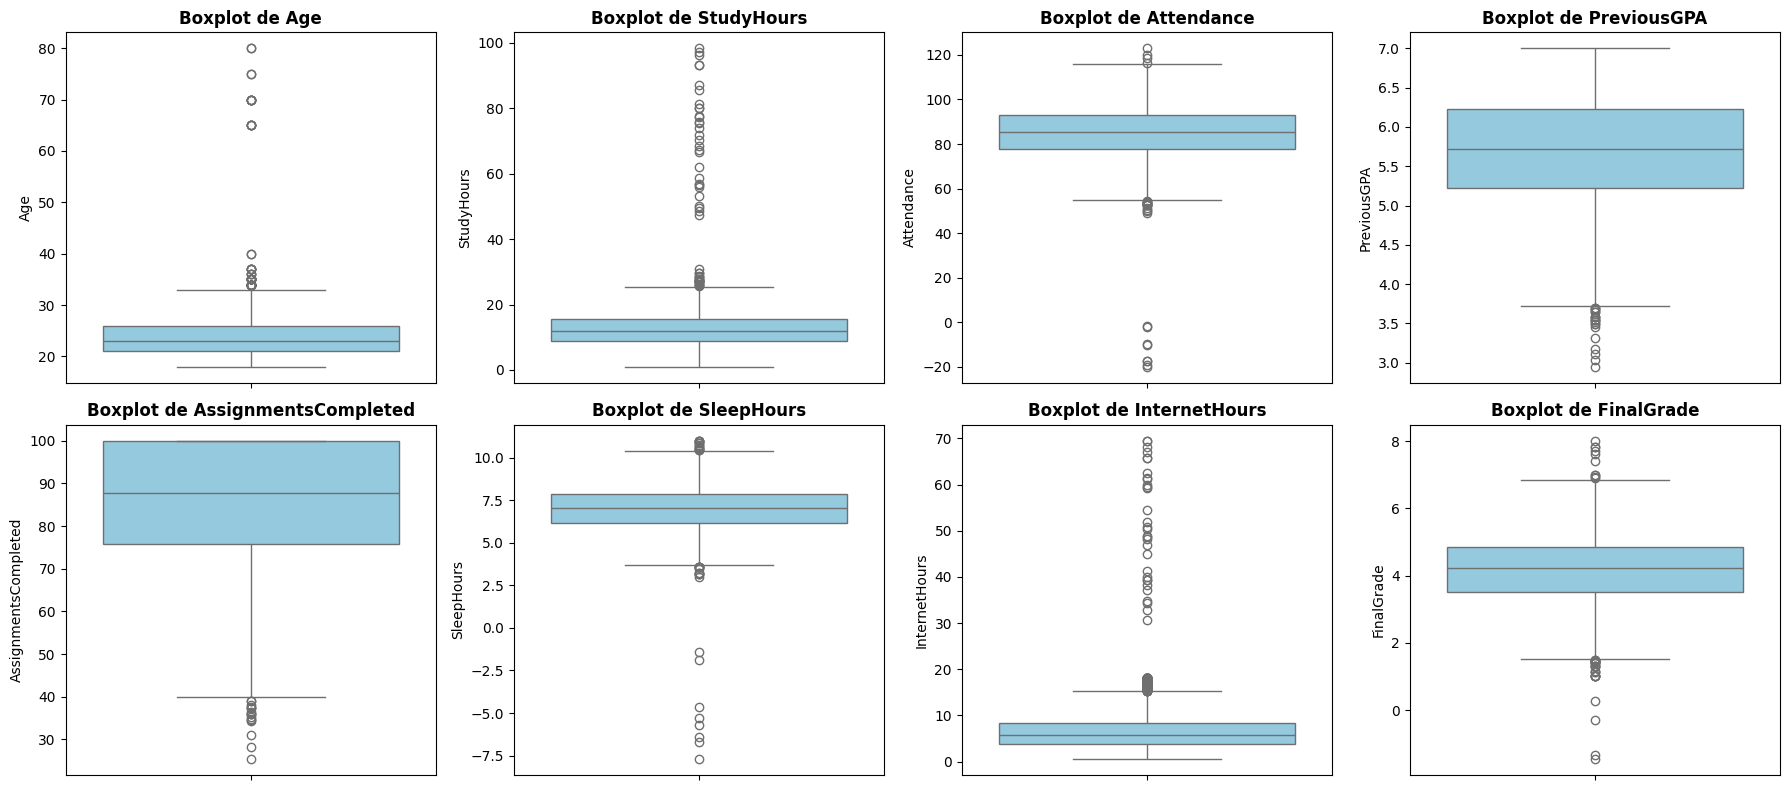

In [ ]:
# 1. Definir las variables numéricas que vamos a graficar
columnas_numericas = ["Age", "StudyHours", "Attendance", "PreviousGPA",
                      "AssignmentsCompleted", "SleepHours", "InternetHours", "FinalGrade"]

# 2. Crear la figura (2 filas, 4 columnas = 8 espacios)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

# 3. Aplanar la cuadrícula para poder usar los números del 0 al 7
axes = axes.flatten()

# 4. Graficar automáticamente cada variable en su respectivo espacio
for i, col in enumerate(columnas_numericas):
    sns.boxplot(y=data[col], ax=axes[i], color="skyblue")
    axes[i].set_title(f"Boxplot de {col}", fontsize=12, fontweight="bold")

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

### Análisis de Valores Atípicos (Boxplots)

La evaluación visual de las distribuciones mediante diagramas de caja revela dos hallazgos fundamentales sobre la calidad de los datos originales:

*   **Alta dispersión y valores extremos (Outliers):** Variables como `StudyHours`, `InternetHours` y `Age` concentran a la mayoría de los estudiantes en rangos bajos, pero presentan una gran cantidad de valores atípicos extremos hacia arriba (ej. registros de casi 100 horas de estudio). Esto justifica técnicamente la decisión de utilizar la Mediana para imputar faltantes y aplicar un escalador robusto (`RobustScaler`) en el tratamiento.
*   **Errores e inconsistencias lógicas:** Los gráficos exponen claramente valores físicamente imposibles, como registros negativos (por debajo de 0) en las variables `Attendance`, `SleepHours` y `FinalGrade`. Esto evidencia la baja calidad del dato crudo y respalda de manera concluyente la necesidad del filtrado de inconsistencias realizado en la etapa de limpieza.

In [ ]:
# Detección de outliers para todas las variables numéricas de tu dataset
outliers_age = diagnostico_outliers_iqr(data, "Age")
outliers_study_hours = diagnostico_outliers_iqr(data, "StudyHours")
outliers_attendance = diagnostico_outliers_iqr(data, "Attendance")
outliers_gpa = diagnostico_outliers_iqr(data, "PreviousGPA")
outliers_assignments = diagnostico_outliers_iqr(data, "AssignmentsCompleted")
outliers_sleep_hours = diagnostico_outliers_iqr(data, "SleepHours")
outliers_internet_hours = diagnostico_outliers_iqr(data, "InternetHours")
outliers_final_grade = diagnostico_outliers_iqr(data, "FinalGrade")

--- Análisis IQR para la variable 'Age' ---
Q1: 21.00 | Q3: 26.00 | IQR: 5.00
Límite Inferior: 13.50 | Límite Superior: 33.50
Registros fuera de límites: 63 (1.24%)

--- Análisis IQR para la variable 'StudyHours' ---
Q1: 8.75 | Q3: 15.44 | IQR: 6.69
Límite Inferior: -1.29 | Límite Superior: 25.48
Registros fuera de límites: 49 (0.96%)

--- Análisis IQR para la variable 'Attendance' ---
Q1: 77.58 | Q3: 93.01 | IQR: 15.43
Límite Inferior: 54.43 | Límite Superior: 116.16
Registros fuera de límites: 27 (0.53%)

--- Análisis IQR para la variable 'PreviousGPA' ---
Q1: 5.22 | Q3: 6.23 | IQR: 1.01
Límite Inferior: 3.70 | Límite Superior: 7.75
Registros fuera de límites: 21 (0.41%)

--- Análisis IQR para la variable 'AssignmentsCompleted' ---
Q1: 75.85 | Q3: 100.00 | IQR: 24.15
Límite Inferior: 39.62 | Límite Superior: 136.23
Registros fuera de límites: 17 (0.33%)

--- Análisis IQR para la variable 'SleepHours' ---
Q1: 6.16 | Q3: 7.86 | IQR: 1.70
Límite Inferior: 3.61 | Límite Superior: 10.41
R

##**Inconsistencias**

In [ ]:
regla_edad = (data['Age'] < 16) | (data['Age'] > 99)
regla_asistencia = (data['Attendance'] < 0) | (data['Attendance'] > 100)
regla_notas_previas = (data['PreviousGPA'] < 1.0) | (data['PreviousGPA'] > 7.0)
regla_nota_final = (data['FinalGrade'] < 1.0) | (data['FinalGrade'] > 7.0)
regla_sueno = (data['SleepHours'] < 0) | (data['SleepHours'] > 24)
regla_horas_estudio = (data['StudyHours'] < 0)
regla_horas_internet = (data['InternetHours'] < 0)

filtro_inconsistencias = (regla_edad | regla_asistencia | regla_notas_previas |
                          regla_nota_final | regla_sueno | regla_horas_estudio |
                          regla_horas_internet)
inconsistentes = data[filtro_inconsistencias]
print(f"Total de registros con inconsistencias lógicas: {len(inconsistentes)}")

Total de registros con inconsistencias lógicas: 38


In [ ]:
# Mostrar ejemplos claros de registros con inconsistencias lógicas
cols_clave = ['StudentID', 'Age', 'Attendance', 'PreviousGPA', 'SleepHours', 'FinalGrade']
inconsistentes[cols_clave].head(6)

,StudentID,Age,Attendance,PreviousGPA,SleepHours,FinalGrade
5,STU-11440,21.0,-19.961240,6.69,5.720000,4.650000
16,STU-13555,26.0,111.567467,4.69,NaN,3.050000
263,STU-12872,NaN,80.960000,5.54,6.820000,-1.328245
368,STU-13264,NaN,91.320000,6.73,6.670000,7.824238
583,STU-14004,21.0,95.480000,5.59,-7.713498,5.030000
740,STU-12862,18.0,73.230000,5.15,-6.725603,3.400000


# Análisis exploratorio de datos

## Tipos de datos

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   StudentID             5100 non-null   object 
 1   Age                   4997 non-null   float64
 2   StudyHours            4919 non-null   float64
 3   Attendance            4876 non-null   float64
 4   PreviousGPA           4938 non-null   float64
 5   AssignmentsCompleted  4884 non-null   float64
 6   SleepHours            4978 non-null   float64
 7   InternetHours         4924 non-null   float64
 8   Scholarship           5019 non-null   object 
 9   Program               5030 non-null   object 
 10  FinalGrade            5100 non-null   float64
dtypes: float64(8), object(3)
memory usage: 438.4+ KB


## Medidas estadísticas variables continuas

In [ ]:
data.drop(columns=["StudentID", "FinalGrade"]).describe().round(3)

,Age,StudyHours,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,InternetHours
count,4997.000,4919.000,4876.000,4938.000,4884.000,4978.000,4924.000
mean,23.797,12.425,84.661,5.710,85.214,6.990,6.675
std,4.651,6.879,11.176,0.732,14.241,1.331,5.058
min,18.000,1.000,-19.961,2.950,25.340,-7.713,0.500
25%,21.000,8.750,77.578,5.220,75.848,6.160,3.800
50%,23.000,12.010,85.490,5.725,87.760,7.030,5.820
75%,26.000,15.440,93.010,6.230,100.000,7.860,8.390
max,80.000,98.329,122.974,7.000,100.000,11.000,69.501


## Medidas estadísticas variables discretas

In [ ]:
data.drop(columns=["StudentID"]).describe(include="object")

,Scholarship,Program
count,5019,5030
unique,7,12
top,No,Ingeniería Informática
freq,3364,1424


## Distribución de variables

In [ ]:
# 1. Seleccionar subconjunto de variables numéricas continuas clave
numeric_cols = [
    "Age",
    "StudyHours",
    "Attendance",
    "PreviousGPA",
    "AssignmentsCompleted",
    "SleepHours",
    "InternetHours",
    "FinalGrade"
]

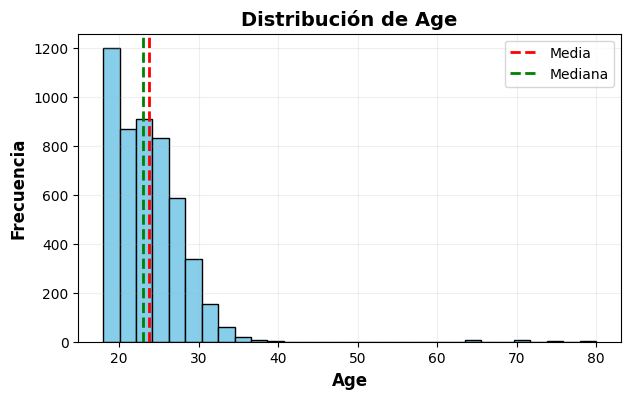

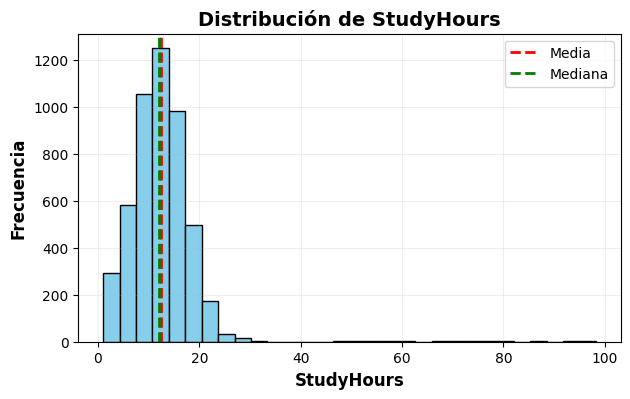

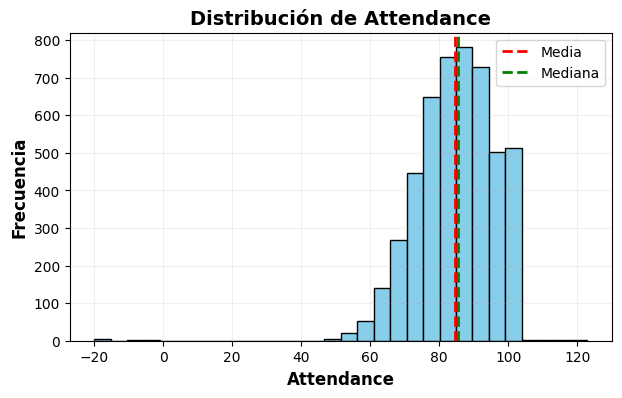

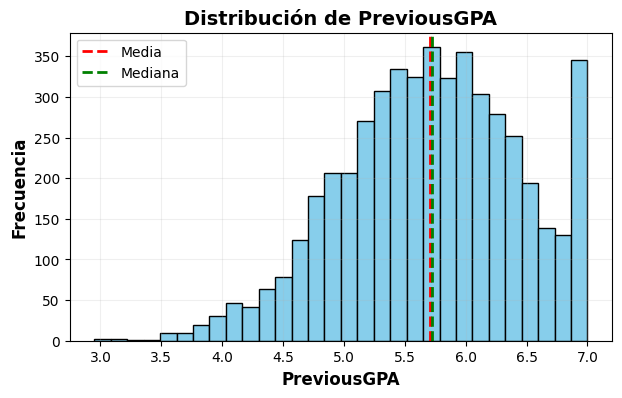

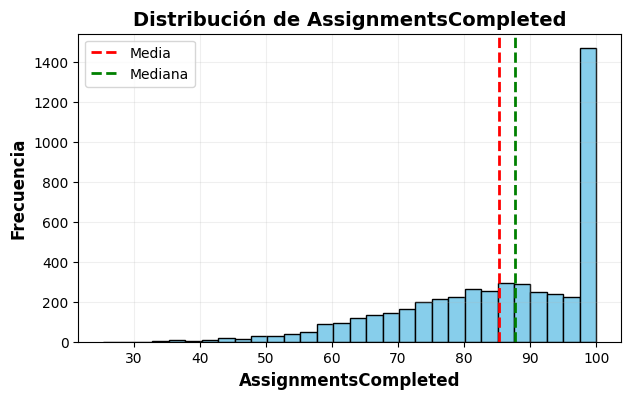

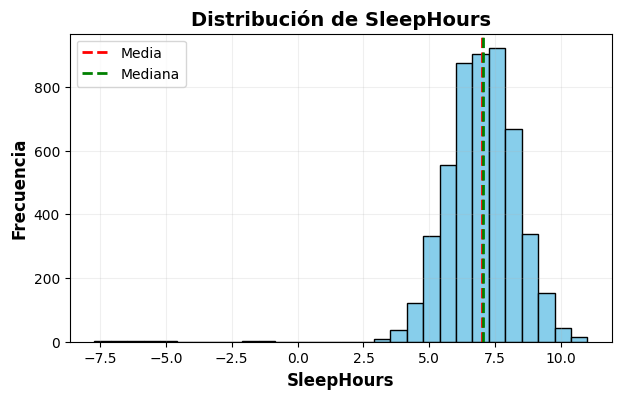

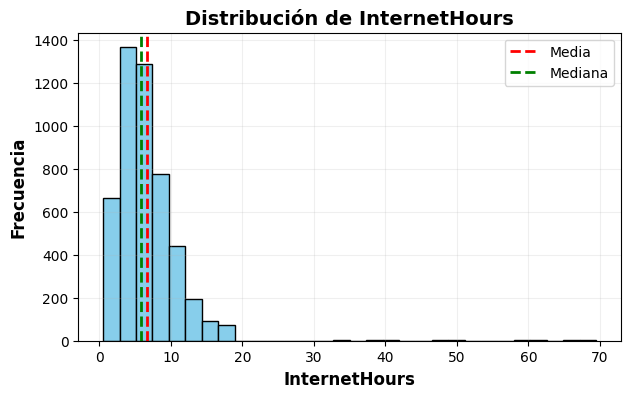

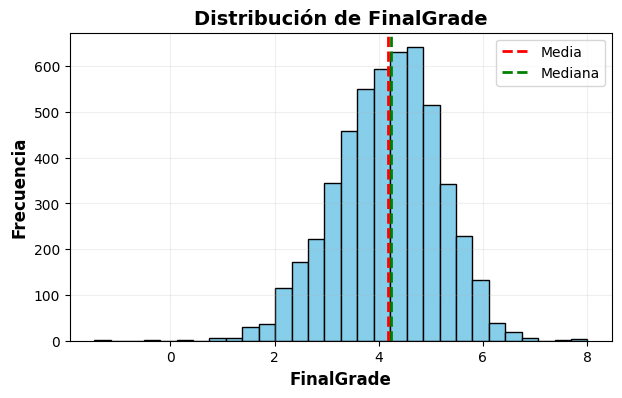

In [ ]:
# 2. Generar la distribución (histogramas) para cada variable
data_analisis = data.copy()

for variable in numeric_cols:
    plt.figure(figsize=(7, 4))

    # Histograma (usando dropna() para evitar errores con los valores faltantes)
    plt.hist(data_analisis[variable].dropna(), bins=30, edgecolor="black", color="skyblue")

    # Líneas de Media y Mediana
    plt.axvline(data_analisis[variable].mean(), color="red", linestyle="dashed", linewidth=2, label="Media")
    plt.axvline(data_analisis[variable].median(), color="green", linestyle="dashed", linewidth=2, label="Mediana")

    # Agrega las etiquetas
    plt.legend()
    plt.title(f"Distribución de {variable}", fontsize=14, fontweight="bold")
    plt.xlabel(variable, fontsize=12, fontweight="bold")
    plt.ylabel("Frecuencia", fontsize=12, fontweight="bold")

    plt.grid(alpha=0.2)
    plt.show()

### Análisis de Distribuciones de Variables Numéricas

La evaluación visual de los histogramas revela tres comportamientos principales, los cuales validan el tratamiento de datos aplicado:

*   **Distribuciones Normales (Simétricas):** Variables como `FinalGrade`, `PreviousGPA` y `SleepHours` presentan una forma de campana clásica (media y mediana superpuestas). La simetría de la variable objetivo (`FinalGrade`) es el escenario ideal para el posterior entrenamiento de modelos predictivos.
*   **Asimetría Positiva (Sesgo a la derecha):** `StudyHours`, `InternetHours` y `Age` concentran sus registros en rangos bajos, dejando una larga cola a la derecha debido a la presencia de valores extremos. Esto justifica matemáticamente la decisión de haber utilizado la mediana para imputar sus valores faltantes.
*   **Asimetría Negativa (Sesgo a la izquierda):** `Attendance` y `AssignmentsCompleted` acumulan a la gran mayoría de los estudiantes en los valores más altos. Además, el gráfico de asistencia evidencia registros físicamente imposibles (valores por debajo de 0), lo que respalda de manera concluyente la necesidad del filtrado de inconsistencias lógicas que se realizó.

In [ ]:
# Contar frecuencias para el Programa Académico
frecuencias_programa = data["Program"].value_counts()
print("--- Cantidad de estudiantes por Programa Académico ---")
display(frecuencias_programa)

# Contar frecuencias para la Beca
frecuencias_beca = data["Scholarship"].value_counts()
print("\n--- Cantidad de estudiantes con y sin Beca ---")
display(frecuencias_beca)

--- Cantidad de estudiantes por Programa Académico ---


,count
Program,
Ingeniería Informática,1424
Ingeniería Industrial,1119
Ingeniería Civil,1004
Administración,787
Contador Auditor,660
Ingenieria Informatica,10
INGENIERÍA INFORMÁTICA,7
Ingeniería Civil,5
INGENIERÍA CIVIL,4



--- Cantidad de estudiantes con y sin Beca ---


,count
Scholarship,
No,3364
Sí,1620
si,10
No,10
NO,8
SÍ,5
SI,2


In [ ]:

# Porcentajes para el Programa Académico
porcentajes_programa = (
    data["Program"].value_counts(normalize=True)* 100
)
print("--- Porcentaje de estudiantes por Programa Académico ---")
display(porcentajes_programa.round(2))

# Porcentajes para la Beca
porcentajes_beca = (
    data["Scholarship"]
    .value_counts(normalize=True)
    * 100
)
print("\n--- Porcentaje de estudiantes con y sin Beca ---")
display(porcentajes_beca.round(2))

--- Porcentaje de estudiantes por Programa Académico ---


,proportion
Program,
Ingeniería Informática,28.31
Ingeniería Industrial,22.25
Ingeniería Civil,19.96
Administración,15.65
Contador Auditor,13.12
Ingenieria Informatica,0.20
INGENIERÍA INFORMÁTICA,0.14
Ingeniería Civil,0.10
INGENIERÍA CIVIL,0.08



--- Porcentaje de estudiantes con y sin Beca ---


,proportion
Scholarship,
No,67.03
Sí,32.28
si,0.20
No,0.20
NO,0.16
SÍ,0.10
SI,0.04


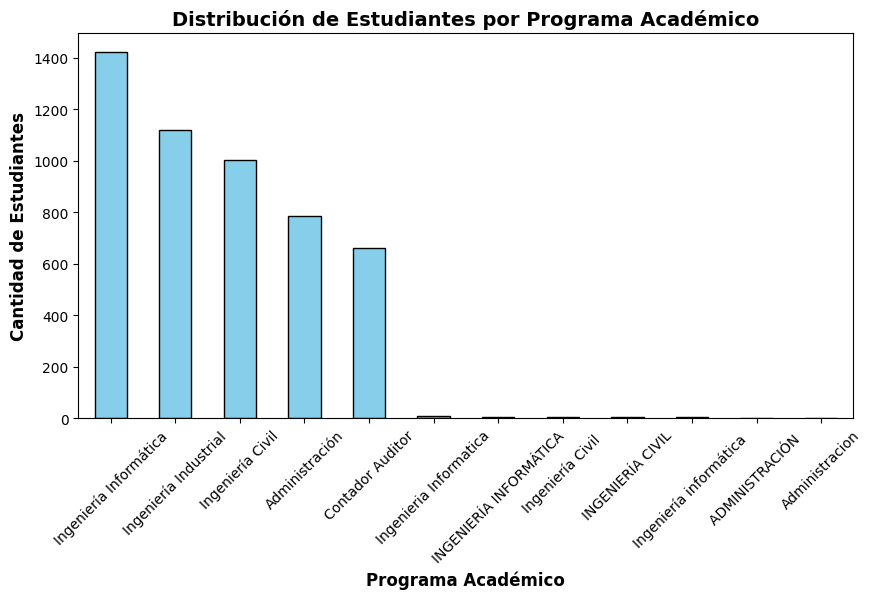

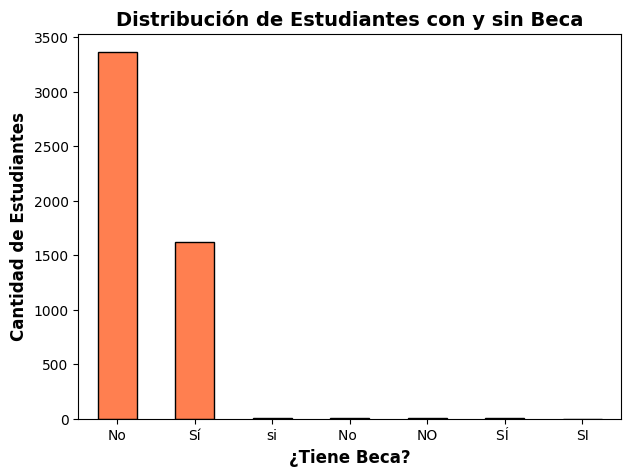

In [ ]:
# 1. Gráfico de barras para el Programa Académico
plt.figure(figsize=(10, 5))
data["Program"].value_counts().plot(
    kind="bar", color="skyblue", edgecolor="black"
)
plt.title("Distribución de Estudiantes por Programa Académico", fontsize=14, fontweight="bold")
plt.xlabel("Programa Académico", fontsize=12, fontweight="bold")
plt.ylabel("Cantidad de Estudiantes", fontsize=12, fontweight="bold")
plt.xticks(rotation=45) # Rotamos el texto para que las carreras se lean bien
plt.show()

# 2. Gráfico de barras para la Beca
plt.figure(figsize=(7, 5))
data["Scholarship"].value_counts().plot(
    kind="bar", color="coral", edgecolor="black"
)
plt.title("Distribución de Estudiantes con y sin Beca", fontsize=14, fontweight="bold")
plt.xlabel("¿Tiene Beca?", fontsize=12, fontweight="bold")
plt.ylabel("Cantidad de Estudiantes", fontsize=12, fontweight="bold")
plt.xticks(rotation=0)
plt.show()

### Análisis de Variables Categóricas e Inconsistencias

La visualización de las variables categóricas permite identificar tanto la distribución de los estudiantes como problemas críticos en la calidad de los datos crudos:

*   **Programas Académicos:** La mayor concentración de la población estudiantil pertenece a Ingeniería Informática, seguida por Ingeniería Industrial e Ingeniería Civil.
*   **Becas:** La gran mayoría de los estudiantes no cuenta con una beca, superando por más del doble al grupo que sí la posee.
*   **Evidencia de Inconsistencias:** Ambos gráficos exponen claramente la creación de categorías duplicadas falsas debido a errores de digitación, tales como el uso mixto de mayúsculas, falta de tildes y espacios en blanco ("si", "SI", "Ingeniería Civil "). Esta representación gráfica es la evidencia visual que justifica la necesidad ineludible de haber aplicado técnicas de estandarización de texto para no alterar ni sesgar los cálculos estadísticos posteriores.

## Análisis bivariado

In [ ]:
# 1. Definir la función para crear gráficos de dispersión (Scatter Plot)
def scatter_plot(data: pd.DataFrame, x: str, y: str):
    """
    Genera un gráfico de dispersión (scatter plot) para dos variables.
    """
    plt.figure(figsize=(8, 5))

    # alpha=0.5 hace que los puntos sean semitransparentes para ver donde se agrupan
    plt.scatter(data[x], data[y], alpha=0.5, color="steelblue")

    plt.xlabel(x, fontsize=14, fontweight="bold")
    plt.ylabel(y, fontsize=14, fontweight="bold")
    plt.title(f"{x} vs {y}", fontsize=16, fontweight="bold")

    plt.grid(alpha=0.2)
    plt.show()

## StudyHours versus FinalGrade

1. Relación entre Horas de Estudio y Nota Final


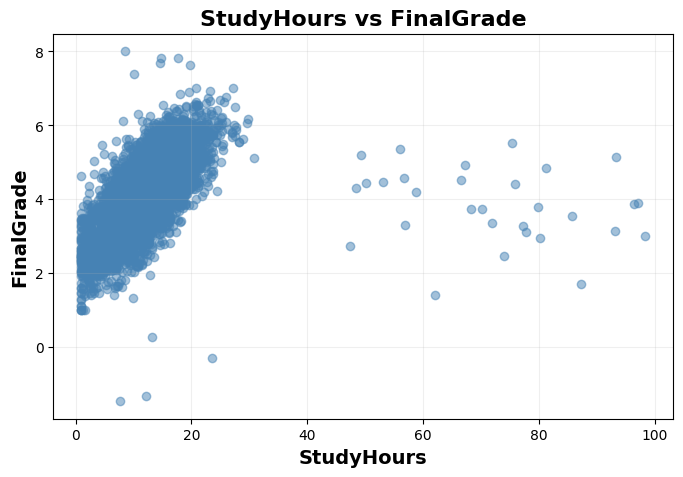

In [ ]:
print("1. Relación entre Horas de Estudio y Nota Final")
scatter_plot(data, "StudyHours", "FinalGrade")

###StudyHours vs FinalGrade

Se observa una **tendencia lineal positiva**. A medida que aumentan las horas de estudio, las calificaciones finales tienden a incrementar. Esta correlación directa aporta un alto valor predictivo para el futuro modelo, a pesar de la presencia visual de algunos valores atípicos (estudiantes con más de 40 horas de estudio) a la derecha del gráfico. Es importante destacar de cara al modelado que las variables con correlaciones lineales negativas resultarían exactamente igual de útiles e informativas que estas relaciones positivas.

##  Attendace versus FinalGrade

2. Relación entre Asistencia y Nota Final 


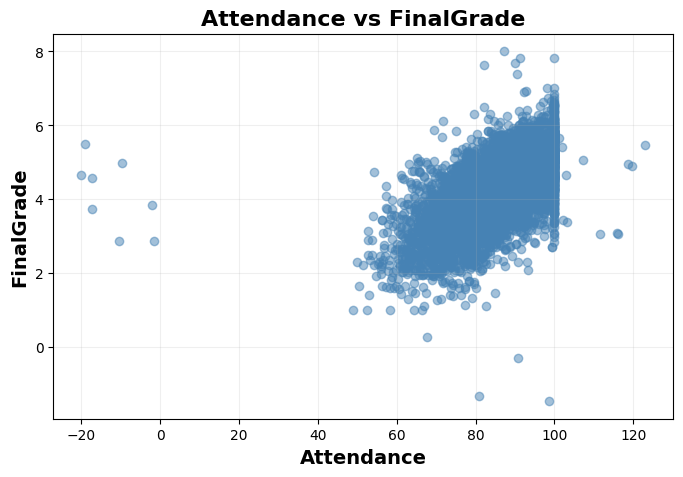

In [ ]:
print("2. Relación entre Asistencia y Nota Final ")
scatter_plot(data, "Attendance", "FinalGrade")

###Attendance vs FinalGrade

Existe una **correlación lineal positiva evidente**. La gran masa de datos asciende de forma compacta hacia el cuadrante superior derecho, demostrando que una mayor asistencia se traduce directamente en mejores calificaciones. Adicionalmente, este gráfico expone visualmente los registros erróneos de asistencia negativa (menores a 0) que justificaron el filtrado de inconsistencias lógicas en la etapa previa.

## PreviousGPA versus FinalGrade

3. Relación entre GPA Previo y Nota Final


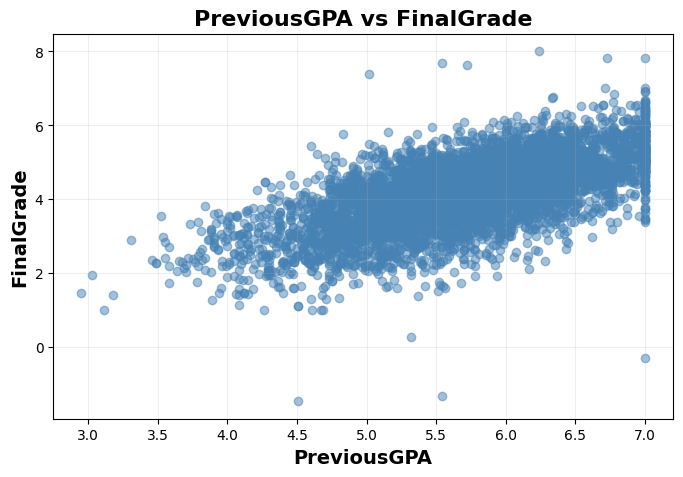

In [ ]:
print("3. Relación entre GPA Previo y Nota Final")
scatter_plot(data, "PreviousGPA", "FinalGrade")

###PreviousGPA vs FinalGrade

El gráfico muestra una **correlación lineal positiva muy definida y consistente**. El rendimiento académico previo actúa como un predictor directo del rendimiento actual: a mayor nota histórica (GPA), mayor es la calificación final obtenida. Estadísticamente, esta es una de las características más robustas y útiles para alimentar el modelo predictivo.

## InternetHours versus FinalGrade

4. Relación entre Horas de Internet y Nota Final


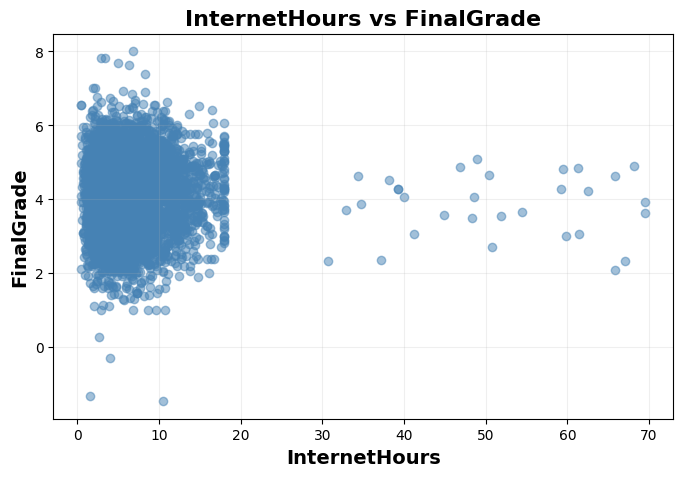

In [ ]:
print("4. Relación entre Horas de Internet y Nota Final")
scatter_plot(data, "InternetHours", "FinalGrade")

###InternetHours vs FinalGrade

A diferencia del resto de las variables, en este caso **no se observa una correlación lineal clara**. Los datos se agrupan en un bloque denso vertical sin una pendiente definida (ni ascendente ni descendente), lo que indica que la cantidad de horas de uso de internet no tiene un impacto directo lineal en la nota final. En una futura fase de selección de variables, esta característica aportaría un bajo poder predictivo.

## AssigmentsCompleted versus FinalGrade

5. Relación entre Tareas Completadas y Nota Final


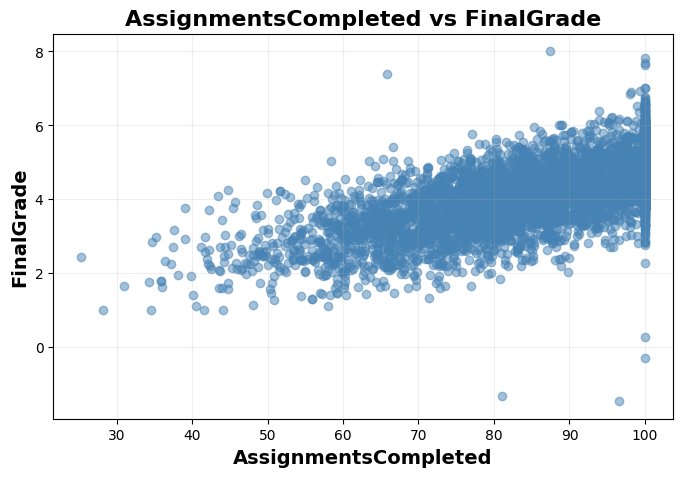

In [ ]:
print("5. Relación entre Tareas Completadas y Nota Final")
scatter_plot(data, "AssignmentsCompleted", "FinalGrade")

###AssignmentsCompleted vs FinalGrade

Se evidencia una **fuerte tendencia lineal positiva**. El bloque de datos asciende claramente hacia la derecha, confirmando visualmente que a mayor cantidad de tareas completadas, mayor es la calificación final obtenida por el estudiante. Esta relación directa e innegable la convierte en otra variable predictora fundamental para la fase de modelado.

## FinalGrade versus Scholarship

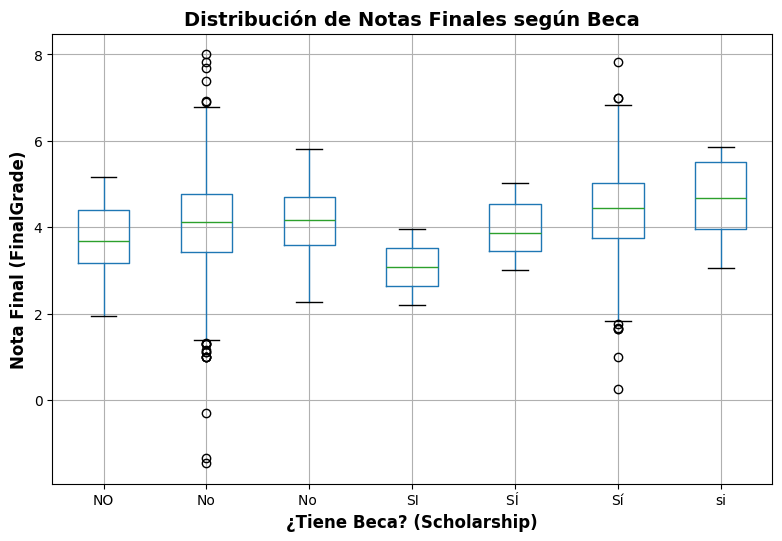

In [ ]:
# Gráfico para responder la Pregunta 1: Notas vs Beca
fig, ax = plt.subplots(figsize=(9, 6))

# Agrupamos la Nota Final (FinalGrade) separada por si tienen Beca (Scholarship)
data.boxplot(column="FinalGrade", by="Scholarship", ax=ax, grid=True)

ax.set_title("Distribución de Notas Finales según Beca", fontsize=14, fontweight="bold")
ax.set_xlabel("¿Tiene Beca? (Scholarship)", fontsize=12, fontweight="bold")
ax.set_ylabel("Nota Final (FinalGrade)", fontsize=12, fontweight="bold")

fig.suptitle("") # Esto quita un título automático que pone Pandas arriba
plt.show()

###Distribución de Notas Finales según Beca

El diagrama de caja revela una severa fragmentación de los datos debido a errores tipográficos en los registros crudos.
*   Se observan múltiples variaciones redundantes para las categorías, tales como "NO", "No", "No " y "SI", "SÍ", "Sí", "si".
*   Adicionalmente, el gráfico expone claramente la presencia de dispersión extrema (outliers) y calificaciones negativas en el eje vertical, lo cual es lógicamente imposible.
*   Esta representación visual justifica de manera irrefutable la necesidad de haber aplicado técnicas de limpieza y estandarización de texto para no falsear los promedios reales.

## FinalGrade versus Program

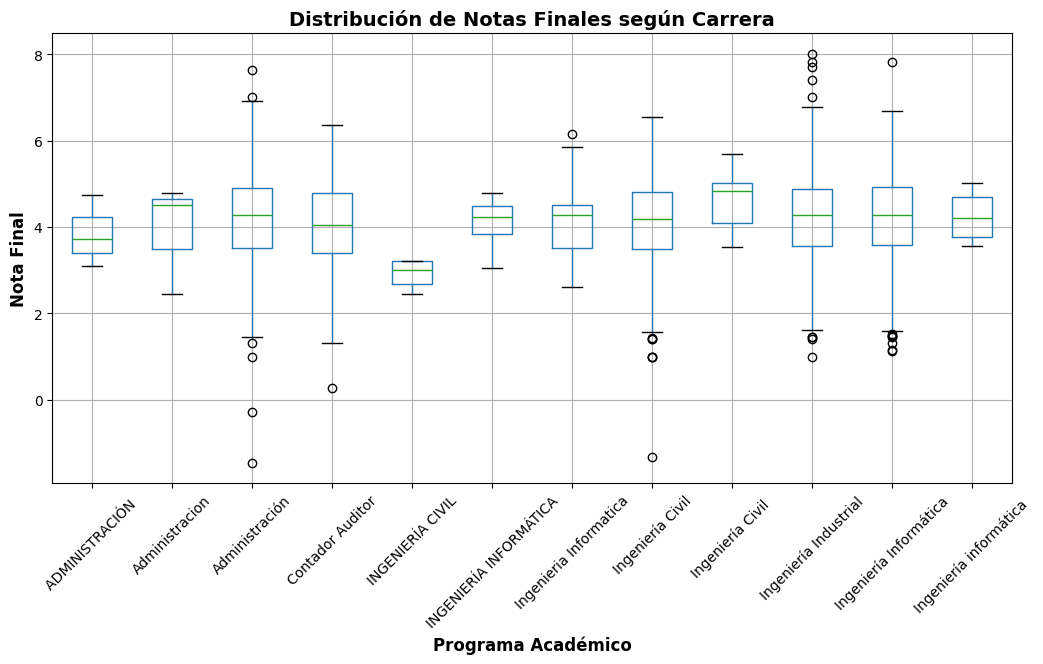

In [ ]:
# Gráfico extra: Notas vs Programa Académico
fig, ax = plt.subplots(figsize=(12, 6))

data.boxplot(column="FinalGrade", by="Program", ax=ax, grid=True)

ax.set_title("Distribución de Notas Finales según Carrera", fontsize=14, fontweight="bold")
ax.set_xlabel("Programa Académico", fontsize=12, fontweight="bold")
ax.set_ylabel("Nota Final", fontsize=12, fontweight="bold")
plt.xticks(rotation=45) # Rotamos los nombres para que se lean bien

fig.suptitle("")
plt.show()

###Distribución de Notas Finales según Carrera

La visualización expone la creación de categorías falsas originadas por el uso inconsistente de mayúsculas, tildes y espacios ocultos en la digitación.
*   Estas fallas provocan que los estudiantes de un mismo programa académico (como Ingeniería Civil o Administración) se dividan en grupos aislados que muestran medianas y distribuciones estadísticas drásticamente diferentes entre sí.
*   Al igual que en la variable anterior, se confirma visualmente la existencia de valores atípicos y notas por debajo de cero.
*   Este gráfico constituye la evidencia técnica definitiva de que, de haber omitido la estandarización categórica, cualquier cálculo comparativo o modelo predictivo habría entregado resultados matemáticamente erróneos.

In [ ]:
# Cálculo exacto para la Pregunta 1: Diferencia de promedios según Beca
resumen_beca = (
    data.groupby("Scholarship")["FinalGrade"]
    .agg(["count", "mean", "median", "std"])
)

print("--- Resumen estadístico de Notas Finales agrupado por Beca ---")
display(resumen_beca.round(2))

--- Resumen estadístico de Notas Finales agrupado por Beca ---


,count,mean,median,std
Scholarship,,,,
NO,8,3.73,3.68,1.05
No,3364,4.07,4.12,1.00
No,10,4.10,4.16,1.17
SI,2,3.08,3.08,1.23
SÍ,5,3.98,3.88,0.81
Sí,1620,4.37,4.44,0.93
si,10,4.64,4.69,1.00


## Análisis de StudyHours con atípicos

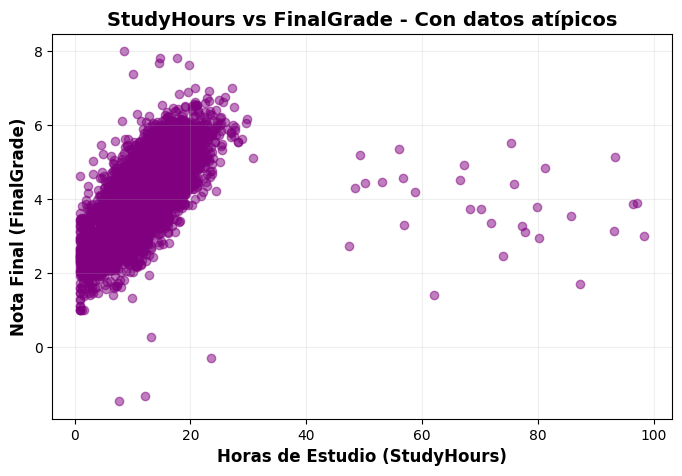

In [ ]:
# Gráfico para visualizar los atípicos antes del tratamiento
plt.figure(figsize=(8, 5))

plt.scatter(
    data["StudyHours"],
    data["FinalGrade"],
    alpha=0.5,
    color="purple" # Le puse otro color para diferenciarlo de los anteriores
)

plt.xlabel("Horas de Estudio (StudyHours)", fontsize=12, fontweight="bold")
plt.ylabel("Nota Final (FinalGrade)", fontsize=12, fontweight="bold")
plt.title("StudyHours vs FinalGrade - Con datos atípicos", fontsize=14, fontweight="bold")

plt.grid(alpha=0.2)
plt.show()

###Valores Atípicos (StudyHours vs FinalGrade)

La visualización del conjunto de datos completo evidencia una alta concentración de estudiantes que siguen una clara tendencia ascendente. Sin embargo, la presencia de valores extremos (registros aislados que superan las 40 y alcanzan casi las 100 horas de estudio) introduce un fuerte "ruido" estadístico. Estos puntos alejados a la derecha del gráfico rompen el patrón lógico principal y no representan a la población general, lo cual justifica técnicamente la necesidad de utilizar un escalador robusto (`RobustScaler`) para evitar que estos casos excepcionales desvíen el aprendizaje de un futuro modelo predictivo.

## Analisis de StudyHours sin atípicos

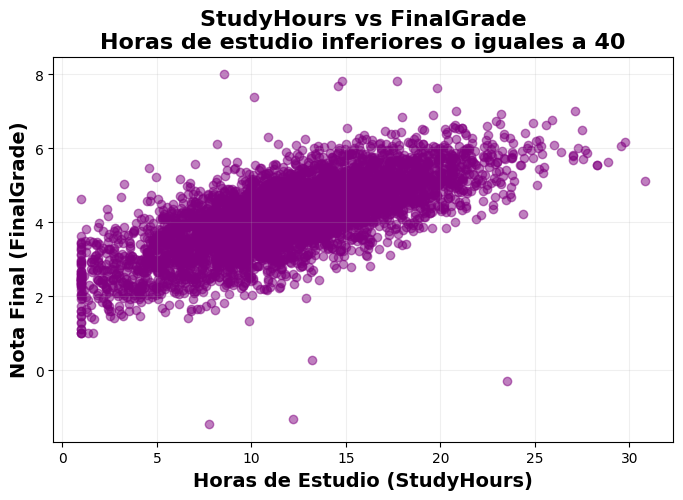

In [ ]:
# 1. Filtramos los datos para quitar los valores extremos (dejamos solo <= 40 horas)
data_sin_extremos = data[data["StudyHours"] <= 40]

# 2. Volvemos a generar el gráfico con los datos limpios
plt.figure(figsize=(8, 5))

plt.scatter(
    data_sin_extremos["StudyHours"],
    data_sin_extremos["FinalGrade"],
    alpha=0.5,
    color="purple" # Mismo color para que sea fácil comparar con el anterior
)

plt.xlabel("Horas de Estudio (StudyHours)", fontsize=14, fontweight="bold")
plt.ylabel("Nota Final (FinalGrade)", fontsize=14, fontweight="bold")
plt.title("StudyHours vs FinalGrade\nHoras de estudio inferiores o iguales a 40", fontsize=16, fontweight="bold")

plt.grid(alpha=0.2)
plt.show()

###Análisis de la Tendencia Filtrada (Horas de estudio menores o iguales a 40)

Al aplicar un filtro visual para aislar a la población general, la **correlación lineal positiva** se vuelve innegable. Se observa un bloque sumamente denso y compacto que asciende uniformemente, confirmando con alta certeza que el incremento en las horas de estudio impacta de forma directa en la obtención de mejores calificaciones finales.

**Consideración para el modelado:** Esta variable demuestra tener un altísimo poder predictivo. Como principio analítico al seleccionar características para el algoritmo, es vital tener presente que, si bien este es un excelente ejemplo de correlación positiva útil, las variables que presenten correlaciones lineales **negativas** (una tendencia visual hacia abajo) poseen exactamente la misma validez y capacidad de predicción matemática, por lo que son igualmente indispensables para el entrenamiento exitoso del modelo.

## Análisis de interdependencia(Multicolinealidad)

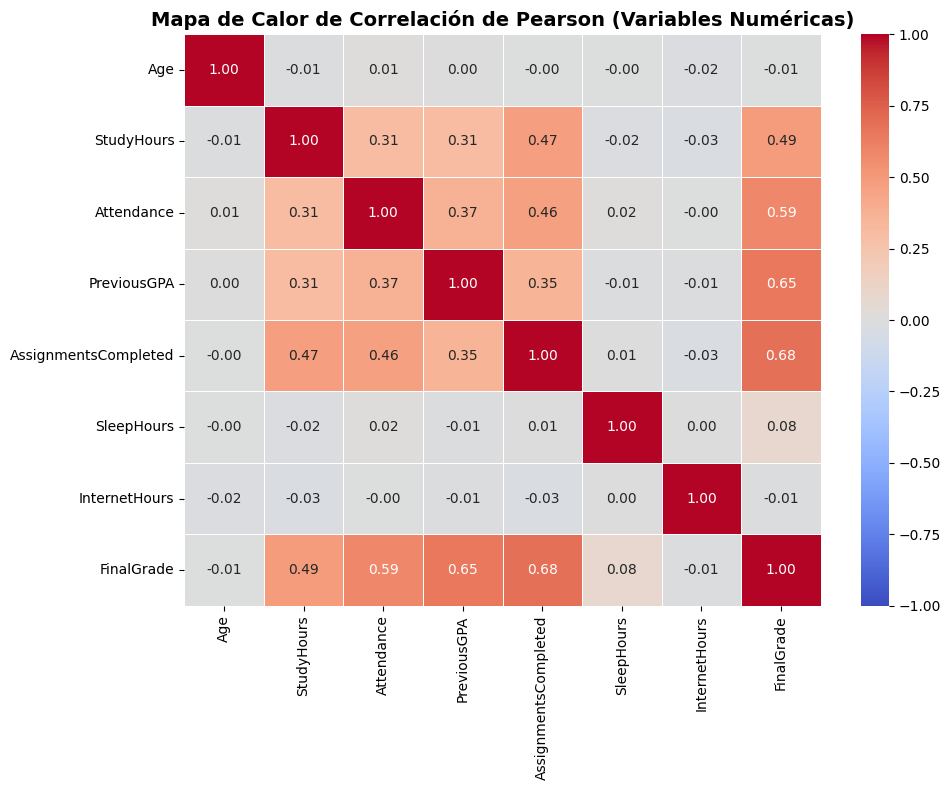

In [ ]:
# 1. Filtramos solo las columnas numéricas usando la lista que ya creamos antes
data_numeric = data[numeric_cols]

# 2. Calcular Coeficiente de Correlación de Pearson
correlation_matrix = data_numeric.corr(method="pearson")

# 3. Dibujar el Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f", # Cambiado a 2 decimales para que se lea mucho mejor
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
)
plt.title("Mapa de Calor de Correlación de Pearson (Variables Numéricas)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Análisis del Mapa de Calor (Correlación de Pearson)

El mapa de calor de Pearson evalúa la intensidad y dirección de las relaciones lineales entre todas las variables numéricas, arrojando valores en una escala de -1 a 1. Al observar la fila/columna de nuestra variable objetivo (`FinalGrade`), se extraen las siguientes conclusiones para la selección de características (Feature Selection):

*   **Predictores Principales (Alta Relevancia):** Las variables con mayor poder predictivo sobre la nota final son las tareas completadas (`AssignmentsCompleted` con **0.68**) y el promedio histórico (`PreviousGPA` con **0.65**). Estas presentan una relación lineal positiva fuerte, lo que las convierte en la base fundamental para el futuro modelo predictivo.
*   **Predictores Secundarios (Relevancia Moderada):** La asistencia (`Attendance` con **0.59**) y las horas de estudio (`StudyHours` con **0.49**) muestran una correlación lineal positiva moderada pero sumamente consistente. Son variables que deben ser obligatoriamente incluidas en el entrenamiento del algoritmo.
*   **Variables sin Impacto (Baja Relevancia):** Características como la edad (`Age` con **-0.01**), las horas de internet (`InternetHours` con **-0.01**) y las horas de sueño (`SleepHours` con **0.08**) presentan valores prácticamente nulos, indicando una ausencia total de relación lineal con el rendimiento académico. Estas características podrían ser descartadas para evitar ruido en el modelo.

**Consideración metodológica para el modelado:**
En este dataset específico, todas las variables útiles resultaron tener correlaciones lineales *positivas*. Sin embargo, de cara al entrenamiento de modelos predictivos, es imperativo establecer que **las correlaciones lineales negativas fuertes (por ejemplo, valores cercanos a -1.00) son matemáticamente igual de predictivas e importantes**. Un error analítico frecuente es escoger exclusivamente las correlaciones positivas asumiendo que son las únicas que sirven, lo cual limitaría drásticamente la capacidad de aprendizaje del modelo al ignorar factores que disminuyen el valor predictivo de forma consistente.

## Definición de variables dependientes (y) e independientes (x)

In [ ]:
# 1. Eliminar duplicados exactos
data = data.drop_duplicates()

# 2. Corregir inconsistencias lógicas en FinalGrade (debe estar entre 1.0 y 7.0)
data.loc[(data["FinalGrade"] < 1.0) | (data["FinalGrade"] > 7.0), "FinalGrade"] = np.nan
data["FinalGrade"] = data["FinalGrade"].fillna(data["FinalGrade"].median())

# 3. Eliminar la variable objetivo y el identificador de las características (X)
X = data.drop(columns=["FinalGrade", "StudentID"])

# 4. Variable objetivo a predecir
y = data["FinalGrade"]

In [ ]:
# División en Train / Test ANTES de cualquier transformación (Paso clave contra Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Dataset de Entrenamiento (X_train): {X_train.shape}")
print(f"Dataset de Prueba (X_test): {X_test.shape}\n")

Dataset de Entrenamiento (X_train): (4000, 9)
Dataset de Prueba (X_test): (1000, 9)



###**Preguntas**

### **¿Existe una diferencia en el promedio de FinalGrade entre los estudiantes que poseen beca y aquellos que no poseen beca? Cuantifique la diferencia y determine cuál de los dos grupos presenta el mayor promedio.**

Sí, existe una diferencia en el promedio de *FinalGrade* entre ambos grupos. Al agrupar los datos, observamos que los estudiantes que **SÍ** poseen beca presentan el mayor promedio académico, con una nota media de **4.37**. Por otro lado, el grupo que **NO** tiene beca obtuvo un promedio de **4.07**.

La diferencia cuantificada entre ambos grupos es de **0.30** puntos a favor de los estudiantes becados.

### **¿Qué programa académico presenta el mayor promedio de FinalGrade y cuál es la diferencia respecto del programa que presenta el menor promedio?**

Tras aplicar una estandarización de texto para agrupar correctamente a los estudiantes de cada carrera, el programa académico que presenta el **mayor promedio** de *FinalGrade* es **Ingeniería Informática** con una nota media de **4.23**.

Por otro lado, el programa que presenta el **menor promedio** es **Contador Auditor** con una nota media de **4.05**.

La diferencia exacta en el rendimiento académico entre el programa más alto y el más bajo de la institución es de **0.19** puntos.

###**¿Existe una relación entre StudyHours y FinalGrade? Determine la dirección de la relación y cuantifique su intencidad mediante una media estadistica apropiada.**

Sí, existe una relación directa entre las horas de estudio (`StudyHours`) y la calificación final (`FinalGrade`).

Como se observa en los gráficos de dispersión, existe una clara tendencia ascendente: a medida que aumentan las horas de estudio, las notas tienden a subir. Al calcular el coeficiente de correlación de Pearson, se cuantifica una intensidad de **0.49**, lo que confirma que se trata de una relación **positiva y moderada**.

Cabe destacar que el primer gráfico evidencia la presencia de valores atípicos extremos (estudiantes que registran más de 50 horas de estudio). Sin embargo, al observar el gráfico filtrado (horas $\le$ 40), la concentración de los datos reafirma la tendencia positiva lineal para la gran mayoría de la población estudiantil.

###**¿Existe una relación entre Attendance y FinalGrade? Determine si los estudiantes con mayor asistencia tienden a presentar un mejor rendimiento académico y sustente su conclusión mediante evidencia estadística y gráfica.**

Sí, existe una relación directa entre la asistencia (`Attendance`) y la calificación final (`FinalGrade`).

Como se evidencia visualmente en el gráfico de dispersión, existe una clara tendencia ascendente: a medida que aumenta el porcentaje de asistencia, las notas tienden a ser más altas. Al calcular el coeficiente de correlación de Pearson, se cuantifica una intensidad de **0.59**, lo que confirma que se trata de una relación **positiva y moderadamente fuerte**.

Cabe destacar que el gráfico muestra una alta concentración de estudiantes en los porcentajes máximos de asistencia (cercanos al 100%), formando un bloque denso en la parte superior derecha. Esto permite sustentar afirmativamente la premisa de la investigación, concluyendo que los estudiantes más constantes y con mayor asistencia tienden a presentar un mejor rendimiento académico.

### Conclusiones EDA

A partir de los análisis estadísticos y visuales realizados sobre el dataset, se extraen las siguientes tres conclusiones generales sobre el comportamiento del rendimiento académico:

**1. El impacto determinante de los hábitos académicos:**
La evidencia estadística demuestra que existe una relación directa y positiva entre el compromiso del estudiante y su calificación final (`FinalGrade`). Según la matriz de correlación de Pearson, factores como las tareas completadas (`AssignmentsCompleted` con **0.68**), la asistencia (`Attendance` con **0.59**) y las horas de estudio (`StudyHours` con **0.49**) son los predictores numéricos más fuertes del éxito académico. Cabe destacar para la futura etapa de entrenamiento de modelos que, si bien en este caso las correlaciones lineales positivas son las que predominan para el éxito académico, las correlaciones lineales negativas son exactamente igual de útiles y válidas; descartarlas al entrenar un modelo es un error que limitaría drásticamente la capacidad predictiva del algoritmo.

**2. La influencia del apoyo financiero (Becas):**
Se comprobó de manera cuantitativa que existe una brecha en el rendimiento final dependiendo de si el estudiante posee o no una beca (`Scholarship`). Tras estandarizar y limpiar las categorías de esta variable, se constató que el grupo con beca superó al grupo sin apoyo financiero por una diferencia de **0.30** puntos en su promedio general (4.37 vs 4.07). Esto sugiere que el respaldo financiero, o las exigencias académicas necesarias para mantenerlo, actúan como un fuerte incentivo que impulsa positivamente las calificaciones.

**3. Heterogeneidad académica y Calidad de los Datos:**
El rendimiento presenta variaciones estructurales dependiendo de la carrera (`Program`). Se evidenció una diferencia de **0.19** puntos entre la carrera de Ingeniería Informática (mayor promedio general con 4.23) y Contador Auditor (menor promedio con 4.05). Además, el análisis exploratorio de esta variable fue fundamental para evaluar la calidad de la información: reveló múltiples inconsistencias tipográficas (uso de mayúsculas, tildes y espacios ocultos) que habrían alterado completamente los cálculos matemáticos, demostrando que el tratamiento y estandarización de las variables categóricas es un paso obligatorio antes de cualquier análisis predictivo.

##Definición de Sub-Pipelines por Tipo de Variable

In [ ]:
# A. Variables numéricas normales (sin presencia severa de outliers)
num_standard_features = [
    "Attendance",
    "PreviousGPA",
    "AssignmentsCompleted",
    "SleepHours"
    # Age se movió al grupo robusto
]
num_standard_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="mean")), # Rellena nulos con el promedio
        ("scaler", StandardScaler()), # Escalado estándar (Z-score)
    ]
)

# B. Variables numéricas con presencia de Outliers severos
num_robust_features = ["StudyHours", "InternetHours", "Age"] # ¡Age se agregó aquí!
num_robust_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")), # Rellena nulos con la mediana
        ("scaler", RobustScaler()), # Escalador resistente a outliers (usa IQR)
    ]
)

# C. Variables categóricas (Texto)
categorical_features = ["Program", "Scholarship"]
categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")), # Rellena nulos con la moda
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)), # Pasa texto a números
    ]
)

# Integración con ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num_std", num_standard_pipeline, num_standard_features),
        ("num_robust", num_robust_pipeline, num_robust_features),
        ("cat", categorical_pipeline, categorical_features),
    ],
    remainder="passthrough"
)

print("¡Pipeline de preprocesamiento configurado con éxito!")

¡Pipeline de preprocesamiento configurado con éxito!


In [ ]:
preprocessor

ColumnTransformer(remainder='passthrough',
                  transformers=[('num_std',
                                 Pipeline(steps=[('imputer', SimpleImputer()),
                                                 ('scaler', StandardScaler())]),
                                 ['Attendance', 'PreviousGPA',
                                  'AssignmentsCompleted', 'SleepHours']),
                                ('num_robust',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['StudyHours', 'InternetHours', 'Age']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['Program', 'Scholarship'])])

#Tratamiento de los Datos: Estrategias y Justificaciones

A continuación se detallan y fundamentan las decisiones tomadas para la preparación del dataset, dando cumplimiento a los requerimientos de calidad y evitando modificaciones sin respaldo estadístico o lógico.

*   **Registros duplicados:** Se procedió a la eliminación de las observaciones que son copias exactas. Cabe destacar que la variable que identifica a cada registro de manera única en este dataset es **`StudentID`**.

    *   **Justificación:** Mantener registros idénticos genera un sobreajuste al otorgar un peso artificial y redundante a ciertas observaciones, lo que sesgaría los resultados del análisis exploratorio y de cualquier modelo predictivo posterior.

*   **Valores faltantes:** La estrategia de imputación se definió de forma diferenciada, respetando la naturaleza y distribución de cada variable:
    *   *Variables categóricas (`Scholarship`, `Program`):* Se imputaron utilizando la **Moda** (valor más frecuente). *Justificación:* Al ser datos cualitativos, la moda es la única medida válida para rellenar vacíos conservando la representatividad de la categoría dominante.
    *   *Variables numéricas con alta dispersión (`StudyHours`, `InternetHours`):* Se imputaron utilizando la **Mediana**. *Justificación:* Al presentar una distribución muy separada o sesgada (con la presencia de valores extremos), la mediana actúa como una medida estadística robusta que no se deja arrastrar por los datos atípicos.
    *   *Variables numéricas con distribución centrada (`Age`, `Attendance`, `PreviousGPA`, `AssignmentsCompleted`, `SleepHours`):* Se imputaron mediante el **Promedio (Media)**. *Justificación:* Al tener una distribución más simétrica y sin una separación extrema, el promedio representa el estimador más preciso para mantener la estructura general de estos datos.

*   **Inconsistencias lógicas:** Los valores que caen fuera de los dominios teóricos posibles (como porcentajes menores a 0 o mayores a 100, o notas fuera de la escala 1.0 - 7.0) se asumen como errores de digitación.
    *   **Justificación:** En lugar de eliminar toda la observación, estos errores se transforman en valores nulos (`NaN`) para que el Pipeline los impute posteriormente con la media o mediana correspondiente. Esto permite rescatar el resto de la información válida del estudiante.

*   **Valores atípicos (Outliers):** Se decidió conservar estas observaciones en el dataset, optando por aislar su impacto mediante un escalado con `RobustScaler` en las variables afectadas.
    *   **Justificación:** En un contexto de educación superior, los valores extremos (como una cantidad muy alta de horas de estudio) pueden representar casos reales de estudiantes excepcionales y contienen alto valor predictivo. El `RobustScaler` utiliza el rango intercuartílico, escalando los datos sin que los outliers distorsionen la muestra.

*   **Variables categóricas:** Se transformaron a formato numérico utilizando la técnica de `OneHotEncoder`.
    *   **Justificación:** Los modelos matemáticos requieren matrices numéricas. Al ser variables nominales sin un orden jerárquico inherente (como las distintas carreras en `Program`), esta técnica crea columnas binarias independientes, evitando que el modelo asuma una falsa relación de magnitud (ej. asumir erróneamente que una carrera vale matemáticamente "más" que otra).

*   **Variables numéricas normales:** Se estandarizaron utilizando `StandardScaler`.
    *   **Justificación:** Permite que las variables compartan la misma escala (media 0 y varianza 1). Esto asegura que atributos con rangos muy distintos (ej. `Attendance` que va de 0 a 100 versus `PreviousGPA` que va de 1.0 a 7.0) posean el mismo peso relativo en el análisis.

*   **Separación de la variable objetivo (`FinalGrade`):** Se aisló completamente del conjunto de variables predictoras (`X`) antes de aplicar cualquier transformación.
    *   **Justificación:** Esta es la variable objetivo a predecir[cite: 4]. Incluirla en transformaciones conjuntas de imputación o escalado provocaría un sesgo conocido como "fuga de datos" (data leakage), invalidando el uso del dataset.

## Ajuste y Transformación de Datos (Zero Data Leakage)

In [ ]:
# 0. CORRECCIÓN DE INCONSISTENCIAS DE TEXTO (Para evitar columnas duplicadas)
data["Scholarship"] = data["Scholarship"].str.strip().str.upper().str.replace("Í", "I")
data["Program"] = data["Program"].str.strip().str.upper().str.replace("Á", "A").str.replace("É", "E").str.replace("Í", "I").str.replace("Ó", "O").str.replace("Ú", "U")

# 1. Volver a dividir los datos ya limpios (Previene el Data Leakage)
X = data.drop(columns=["FinalGrade"])
y = data["FinalGrade"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Fit y Transform SOLO sobre el conjunto de Entrenamiento
X_train_processed = preprocessor.fit_transform(X_train)

# 3. Transform (NUNCA FIT) sobre el conjunto de Prueba
X_test_processed = preprocessor.transform(X_test)

# 4. Obtener nombres de las nuevas columnas generadas por el "Traductor" de texto (OneHotEncoder)
encoded_cat_cols = (
    preprocessor.named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

# 5. Unir todos los nombres de las columnas en el orden correcto
all_feature_names = (
    num_standard_features
    + num_robust_features
    + list(encoded_cat_cols)
)

In [ ]:
all_feature_names

['Attendance',
 'PreviousGPA',
 'AssignmentsCompleted',
 'SleepHours',
 'StudyHours',
 'InternetHours',
 'Age',
 'Program_ADMINISTRACION',
 'Program_CONTADOR AUDITOR',
 'Program_INGENIERIA CIVIL',
 'Program_INGENIERIA INDUSTRIAL',
 'Program_INGENIERIA INFORMATICA',
 'Scholarship_NO',
 'Scholarship_SI']

In [ ]:
X_train_processed.shape

(4000, 15)

In [ ]:
# 1. Detectar automáticamente qué columnas extra se colaron (ej. StudentID)
columnas_extra = [col for col in X_train.columns if col not in (num_standard_features + num_robust_features + categorical_features)]

# 2. Agregar esas columnas a nuestra lista de nombres
all_feature_names_corregido = all_feature_names + columnas_extra

# 3. Convertir de nuevo a DataFrame para verificación (ahora con 15 nombres y 15 columnas)
X_train_prep = pd.DataFrame(X_train_processed, columns=all_feature_names_corregido)

# Mostrar las primeras 3 filas
display(X_train_prep.head(3))

,Attendance,PreviousGPA,AssignmentsCompleted,SleepHours,StudyHours,InternetHours,Age,Program_ADMINISTRACION,Program_CONTADOR AUDITOR,Program_INGENIERIA CIVIL,Program_INGENIERIA INDUSTRIAL,Program_INGENIERIA INFORMATICA,Scholarship_NO,Scholarship_SI,StudentID
0,-0.753112,1.617166,-1.321956,1.952491,-1.525397,-0.466063,0.6,0.0,0.0,0.0,0.0,1.0,0.0,1.0,STU-11023
1,1.378643,1.286222,1.066781,-1.575298,-0.211111,-0.687783,1.8,0.0,0.0,1.0,0.0,0.0,0.0,1.0,STU-12567
2,0.503133,1.217275,1.066781,1.109568,0.685714,0.409502,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,STU-13751


In [ ]:
# 1. Convertir el X_test procesado a DataFrame (tal como hicimos con X_train)
X_test_prep = pd.DataFrame(X_test_processed, columns=all_feature_names_corregido)

# 2. Unir X (variables procesadas) con y (FinalGrade) para los sets de Train y Test
df_train_limpio = pd.concat([X_train_prep.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
df_test_limpio = pd.concat([X_test_prep.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

# 3. Juntar todo en el dataset final estructurado
dataset_limpio = pd.concat([df_train_limpio, df_test_limpio], axis=0).reset_index(drop=True)

# 4. Exportar el archivo final como exige la evaluación
dataset_limpio.to_csv("rendimiento_academico_limpio.csv", index=False)
print("¡Archivo 'rendimiento_academico_limpio.csv' exportado con éxito!")

¡Archivo 'rendimiento_academico_limpio.csv' exportado con éxito!


In [ ]:
print("=== ESTADO FINAL DE CALIDAD (POST-TRATAMIENTO) ===")
print(f"• Total de registros: {len(dataset_limpio)}")
print(f"• Duplicados restantes: {dataset_limpio.duplicated().sum()}")
print(f"• Total general de nulos: {dataset_limpio.isnull().sum().sum()}")
print("-" * 45)
print(f"• Dimensiones del dataset final: {dataset_limpio.shape}")
print(f"• Registros en Train: {len(df_train_limpio)} | Test: {len(df_test_limpio)}")

=== ESTADO FINAL DE CALIDAD (POST-TRATAMIENTO) ===
• Total de registros: 5000
• Duplicados restantes: 0
• Total general de nulos: 0
---------------------------------------------
• Dimensiones del dataset final: (5000, 16)
• Registros en Train: 4000 | Test: 1000


## Tabla Comparativa: Dataset Original vs. Dataset Tratado

| **Indicador** | **Dataset original** | **Dataset tratado** |
|---|---:|---:|
| **Cantidad de registros** | 5100 | 5000 |
| **Cantidad de variables** | 11 | 16 |
| **Valores faltantes** | 1335 | 0 |
| **Registros duplicados** | 100 | 0 |
| **Inconsistencias** | 38 | 0 |
| **Outliers tratados** | No tratados (presentes con alta dispersión) | Sí (aislados mediante RobustScaler) |